#**Travel Mate**

**TravelMate helps users plan personalized trips using travel information and public APIs, while memory allows it to remember destinations, trip duration, interests, and preferences across multiple conversation turns.**

In [1]:
!pip install -q -U langchain langchain-openrouter langgraph pydantic requests httpx

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.5/161.5 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 837.3/837.3 kB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 463.6/463.6 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 47.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [2]:
import os
import requests
import base64
from typing import Optional
import httpx

from pydantic import BaseModel, Field

from langchain.chat_models import init_chat_model
from langchain.messages import (
    SystemMessage,
    HumanMessage,
    AIMessage,
    ToolMessage
)
from langchain.tools import tool
from langchain.agents import create_agent
from langchain_core.runnables import RunnableLambda, RunnablePassthrough
from langgraph.checkpoint.memory import InMemorySaver

In [3]:
import os
from getpass import getpass

os.environ["OPENROUTER_API_KEY"] = getpass("Enter your OpenRouter API key: ")

Enter your OpenRouter API key: ··········


In [4]:
model = init_chat_model(
    "google/gemini-2.5-flash-lite",
    model_provider="openrouter",
    temperature=0.2
)

print("Model initialized successfully.")

Model initialized successfully.


In [5]:
# Structured output schema
class TripRequest(BaseModel):
    destination: Optional[str] = Field(
        default=None,
        description="The country or city the user wants to visit"
    )

    duration_days: Optional[int] = Field(
        default=None,
        ge=1,
        le=60,
        description="Trip duration in days"
    )

    budget_level: Optional[str] = Field(
        default=None,
        description="Budget category: budget, moderate, or luxury"
    )

    interests: list[str] = Field(
        default_factory=list,
        description="Travel interests such as history, beaches, food, nature"
    )

    preferred_weather: Optional[str] = Field(
        default=None,
        description="Preferred weather conditions"
    )

In [6]:
structured_model = model.with_structured_output(TripRequest)

In [7]:
# Test structured output
user_request = """
I want to visit Italy for 7 days.
I have a moderate budget.
I love history, museums and Italian food.
I prefer mild weather.
"""

trip = structured_model.invoke(user_request)

print(trip)
print(type(trip))

destination='Italy' duration_days=7 budget_level='moderate' interests=['history', 'museums', 'food'] preferred_weather='mild'
<class '__main__.TripRequest'>


## **Tools**

In [8]:
# Create open mateo tool
@tool
def get_weather(city: str) -> str:
    """
    Get the current weather and today's forecast for a city.
    Use this when the user asks about weather or travel conditions.
    """

    try:
        # Geocoding
        geo_url = "https://geocoding-api.open-meteo.com/v1/search"

        geo_response = requests.get(
            geo_url,
            params={
                "name": city,
                "count": 1,
                "language": "en",
                "format": "json"
            },
            timeout=10
        )

        geo_response.raise_for_status()

        geo_data = geo_response.json()

        if not geo_data.get("results"):
            return f"Could not find the location: {city}"

        location = geo_data["results"][0]

        latitude = location["latitude"]
        longitude = location["longitude"]
        name = location["name"]
        country = location.get("country", "")

        # Weather
        weather_url = "https://api.open-meteo.com/v1/forecast"

        weather_response = requests.get(
            weather_url,
            params={
                "latitude": latitude,
                "longitude": longitude,
                "current": "temperature_2m,relative_humidity_2m,weather_code,wind_speed_10m",
                "timezone": "auto"
            },
            timeout=10
        )

        weather_response.raise_for_status()

        weather = weather_response.json()["current"]

        return (
            f"Weather for {name}, {country}: "
            f"temperature={weather['temperature_2m']}°C, "
            f"humidity={weather['relative_humidity_2m']}%, "
            f"wind speed={weather['wind_speed_10m']} km/h, "
            f"weather code={weather['weather_code']}."
        )

    except requests.RequestException as e:
        return f"Weather API error: {str(e)}"

    except Exception as e:
        return f"Unexpected weather tool error: {str(e)}"

In [9]:
print(get_weather.invoke("Cairo"))

Weather for Cairo, Egypt: temperature=22.9°C, humidity=89%, wind speed=6.1 km/h, weather code=1.


In [ ]:
import os
import httpx
from langchain_core.tools import tool

RESTCOUNTRIES_API_KEY = ""

def _extract_names(value, key_candidates=("name", "code", "common")):
    """Normalize a field that could be a dict, a list of dicts, or a list of strings
    into a comma-joined string, without assuming the exact v5 shape."""
    if value is None:
        return ""
    if isinstance(value, dict):
        return ", ".join(value.keys())
    if isinstance(value, list):
        parts = []
        for item in value:
            if isinstance(item, str):
                parts.append(item)
            elif isinstance(item, dict):
                for k in key_candidates:
                    if k in item:
                        parts.append(str(item[k]))
                        break
                else:
                    parts.append(str(item))
        return ", ".join(parts)
    return str(value)

@tool
def get_country_info(country_name: str) -> str:
    """Get basic facts about a country: capital, currency, languages, region.
    Uses the REST Countries v5 API (requires a free API key)."""
    try:
        resp = httpx.get(
            f"https://api.restcountries.com/countries/v5/names.common/{country_name}",
            headers={"Authorization": f"Bearer {RESTCOUNTRIES_API_KEY}"},
            timeout=10,
            follow_redirects=True,
        )
        resp.raise_for_status()
        payload = resp.json()

        if "errors" in payload:
            msg = payload["errors"][0].get("message", "Unknown error")
            return f"Country API error: {msg}"

        objects = payload.get("data", {}).get("objects", [])
        if not objects:
            return f"No country found matching '{country_name}'."

        data = objects[0]

        capitals = data.get("capitals", [])
        if capitals and isinstance(capitals[0], dict):
            capital = capitals[0].get("name", "Unknown")
        elif capitals:
            capital = capitals[0]
        else:
            capital = "Unknown"

        currencies = _extract_names(data.get("currencies"), key_candidates=("name", "code"))
        languages = _extract_names(data.get("languages"), key_candidates=("name",))
        region = data.get("region", "Unknown")

        return f"Capital: {capital}, Currencies: {currencies}, Languages: {languages}, Region: {region}"

    except httpx.HTTPStatusError as e:
        return f"Country API error: {e.response.status_code} — {e.response.text[:200]}"
    except httpx.HTTPError as e:
        return f"Country API network error: {e}"
    except (KeyError, IndexError, ValueError) as e:
        return f"Country data malformed: {e}"

# test
print(get_country_info.invoke("Egypt"))

Capital: Cairo, Currencies: Egyptian pound, Languages: Arabic, Region: Africa


In [11]:
tools = [
    get_weather,
    get_country_info
]

print([tool.name for tool in tools])

['get_weather', 'get_country_info']


## **Agent**

In [29]:
memory = InMemorySaver()

SYSTEM_PROMPT = """
You are TravelMate, an AI travel planning assistant.

You help users plan trips and answer travel-related questions.

You have access to these tools:

1. get_weather
2. get_country_info

========================
TOOL USAGE RULES
========================

WEATHER:
- If the user asks about weather, temperature, climate conditions,
  forecast, rain, or similar information, ALWAYS call get_weather.
- Never answer a weather question from your own knowledge.

COUNTRY INFORMATION:
- If the user asks for country facts such as:
  capital, currency, language, region, country information,
  or similar factual information, ALWAYS call get_country_info.
- NEVER answer these questions from your own knowledge.
- Even if you already know the answer, you MUST call get_country_info.
- If the user says "that country", "that place", "there", etc.,
  resolve the reference using the previous conversation and then
  call get_country_info for the resolved country.

========================
MEMORY RULES
========================

- You have conversation memory.
- ALWAYS use previous conversation messages when answering follow-up questions.
- If the user refers to something they previously mentioned,
  retrieve it from the conversation history.
- NEVER ask the user to repeat information that already exists
  in the conversation.
- Current structured information is supplemental context only.
- An empty field in the current structured extraction does NOT mean
  that the user never provided that information.
- Preserve previously provided destination, duration, budget,
  interests, and preferences throughout the conversation.

========================
TRAVEL PLANNING RULES
========================

- Personalize recommendations using information already provided.
- If enough information exists, make a useful recommendation.
- If information is genuinely missing, ask for it.
- Do not invent tool results.
- When a tool is required by the rules above, actually call the tool
  before answering.
"""

agent = create_agent(
    model=model,
    tools=tools,
    system_prompt=SYSTEM_PROMPT,
    checkpointer=memory
)

print("TravelMate agent created successfully.")

TravelMate agent created successfully.


## **Multimodal**

In [13]:
def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(
            image_file.read()
        ).decode("utf-8")

In [18]:
import mimetypes
def get_image_data_url(image_path):
    mime_type, _ = mimetypes.guess_type(image_path)

    if mime_type is None:
        mime_type = "image/jpeg"

    if not mime_type.startswith("image/"):
        raise ValueError(
            "The uploaded file does not appear to be an image."
        )

    image_base64 = encode_image(image_path)

    return f"data:{mime_type};base64,{image_base64}"

## **Validation**

In [14]:
def validate_user_input(user_input):

    if not isinstance(user_input, str):
        raise TypeError("User input must be text.")

    user_input = user_input.strip()

    if not user_input:
        raise ValueError("User input cannot be empty.")

    if len(user_input) > 5000:
        raise ValueError(
            "User input is too long. Please keep it under 5000 characters."
        )

    return user_input

##**Structured Ouptut Connection**

In [15]:
def trip_request_to_context(trip_request: TripRequest) -> str:

    interests = (
        ", ".join(trip_request.interests)
        if trip_request.interests
        else "Not specified"
    )

    return f"""
Structured travel information extracted from the user's request:

Destination:
{trip_request.destination or "Not specified"}

Duration:
{trip_request.duration_days or "Not specified"} days

Budget:
{trip_request.budget_level or "Not specified"}

Interests:
{interests}

Preferred weather:
{trip_request.preferred_weather or "Not specified"}
"""

## **LCEL**

In [16]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

# Fixed LCEL Post-Processing Pipeline
formatter_prompt = PromptTemplate.from_template(
    """You are an invisible text reformatter. Reformat the travel assistant response below to be clear, clean, and organized with bullet points where appropriate.

CRITICAL RULES:
1. Do NOT provide options or multiple versions.
2. Do NOT add commentary, explanations, or setups (e.g., "Here is the formatted version:").
3. Output ONLY the finalized, reformatted travel assistant response directly.

Raw Response:
{response}"""
)

output_formatting_pipeline = (
    {"response": RunnablePassthrough()}
    | formatter_prompt
    | model
    | StrOutputParser()
)

print("LCEL Post-Processing Pipeline updated successfully!")

LCEL Post-Processing Pipeline updated successfully!


In [23]:
def run_agent(
    user_input,
    thread_id="travel_user_2",
    image_path=None
):

    try:
        # =====================================
        # 1. Validate input
        # =====================================

        user_input = validate_user_input(user_input)

        # =====================================
        # 2. Memory configuration
        # =====================================

        config = {
            "configurable": {
                "thread_id": thread_id
            }
        }

        # =====================================
        # 3. Extract structured information
        # =====================================

        try:
            trip_request = structured_model.invoke(
                user_input
            )

            structured_context = trip_request_to_context(
                trip_request
            )

        except Exception as e:

            print(
                "Structured output warning:",
                e
            )

            structured_context = ""

        # =====================================
        # 4. IMPORTANT:
        # Do not force empty structured fields
        # into follow-up questions.
        # =====================================

        useful_structured_info = []

        if trip_request.destination:
            useful_structured_info.append(
                f"Destination: {trip_request.destination}"
            )

        if trip_request.duration_days:
            useful_structured_info.append(
                f"Duration: {trip_request.duration_days} days"
            )

        if trip_request.budget_level:
            useful_structured_info.append(
                f"Budget: {trip_request.budget_level}"
            )

        if trip_request.interests:
            useful_structured_info.append(
                "Interests: "
                + ", ".join(trip_request.interests)
            )

        if trip_request.preferred_weather:
            useful_structured_info.append(
                "Preferred weather: "
                + trip_request.preferred_weather
            )

        # =====================================
        # 5. Build context
        # =====================================

        if useful_structured_info:

            structured_context = (
                "Structured information extracted "
                "from the current user message:\n"
                + "\n".join(
                    useful_structured_info
                )
                + "\n\n"
            )

        else:

            structured_context = (
                "No new structured trip information "
                "was provided in this message.\n\n"
            )

        # =====================================
        # 6. Create message
        # =====================================

        text_content = (
            structured_context
            + "IMPORTANT:\n"
            + "Use the previous conversation history "
            + "to answer follow-up questions. "
            + "Do not ask the user to repeat information "
            + "that they already provided.\n\n"
            + "Current user message:\n"
            + user_input
        )

        # =====================================
        # 7. Text only
        # =====================================

        if image_path is None:

            agent_message = {
                "role": "user",
                "content": text_content
            }

        # =====================================
        # 8. Text + image
        # =====================================

        else:

            image_data_url = get_image_data_url(
                image_path
            )

            agent_message = {
                "role": "user",
                "content": [
                    {
                        "type": "text",
                        "text": text_content
                    },
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": image_data_url
                        }
                    }
                ]
            }

        # =====================================
        # 9. Run agent
        # =====================================

        result = agent.invoke(
            {
                "messages": [
                    agent_message
                ]
            },
            config
        )

        # =====================================
        # 10. Extract response
        # =====================================

        messages = result.get(
            "messages",
            []
        )

        if not messages:
            return (
                "TravelMate did not return a response."
            )

        raw_response = messages[-1].content

        # =====================================
        # 11. Handle content blocks
        # =====================================

        if not isinstance(
            raw_response,
            str
        ):

            if isinstance(
                raw_response,
                list
            ):

                text_parts = []

                for block in raw_response:

                    if isinstance(
                        block,
                        dict
                    ):

                        if block.get("type") == "text":

                            text_parts.append(
                                block.get(
                                    "text",
                                    ""
                                )
                            )

                    elif isinstance(
                        block,
                        str
                    ):

                        text_parts.append(
                            block
                        )

                raw_response = "\n".join(
                    text_parts
                )

            else:

                raw_response = str(
                    raw_response
                )

        # =====================================
        # 12. LCEL formatting
        # =====================================

        formatted_response = (
            output_formatting_pipeline.invoke(
                raw_response
            )
        )

        return formatted_response

    except ValueError as e:

        return f"Invalid input: {e}"

    except Exception as e:

        return (
            f"Agent error: "
            f"{type(e).__name__}: {e}"
        )

In [24]:
print(run_agent(""))

Invalid input: User input cannot be empty.


## **Chatbot Loop**

In [33]:
from google.colab import files

print("🌍 TravelMate AI")
print("Type 'exit' to stop.")
print("-" * 50)

thread_id = "travel_chat"

while True:

    user_input = input("\nYou: ").strip()

    if user_input.lower() == "exit":
        print("TravelMate: Goodbye! ✈️")
        break

    if not user_input:
        print("TravelMate: Please enter a message.")
        continue

    attach_image = input(
        "Attach an image? (y/n): "
    ).strip().lower()

    try:

        # ==============================
        # TEXT ONLY
        # ==============================

        if attach_image != "y":

            response = run_agent(
                user_input,
                thread_id=thread_id
            )

            print("\nTravelMate:", response)

        # ==============================
        # IMAGE + TEXT
        # ==============================

        else:

            print("\nUpload your image:")

            uploaded = files.upload()

            if not uploaded:
                print("No image uploaded.")
                continue

            image_path = list(uploaded.keys())[0]

            image_base64 = encode_image(image_path)

            image_data_url = (
                f"data:image/jpeg;base64,{image_base64}"
            )

            message = HumanMessage(
                content=[
                    {
                        "type": "text",
                        "text": user_input
                    },
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": image_data_url
                        }
                    }
                ]
            )

            config = {
                "configurable": {
                    "thread_id": thread_id
                }
            }

            result = agent.invoke(
                {
                    "messages": [message]
                },
                config
            )

            print(
                "\nTravelMate:",
                result["messages"][-1].content
            )

    except Exception as e:

        print(f"\nTravelMate error: {repr(e)}")

🌍 TravelMate AI
Type 'exit' to stop.
--------------------------------------------------

You: I'm planning a trip to Greece for 7 days. My budget is moderate and I love history, museums, and food.
Attach an image? (y/n): n

TravelMate: Here are a few ideas for your 7-day trip to Greece with a moderate budget:

*   **Athens:**
    *   Explore the Acropolis.
    *   Visit the Acropolis Museum.
    *   Discover the Ancient Agora.
    *   Wander through the Plaka district.
*   **Nafplio:**
    *   Consider a day trip or overnight stay in this beautiful seaside town.
    *   Explore its Venetian fortresses and charming old town.
*   **Crete:**
    *   Spend a few days exploring Minoan history.
    *   Visit the Palace of Knossos.
    *   See the Heraklion Archaeological Museum.
*   **Santorini/Mykonos:**
    *   These islands offer historical sites and culinary experiences.
    *   Be mindful of potential higher costs with a moderate budget.

To help tailor your itinerary further, please in

Saving test travel mate.jpg to test travel mate (1).jpg

TravelMate: This is the Temple of Olympian Zeus in Athens, Greece. Given your interests in history and museums, I believe you would thoroughly enjoy visiting this place. It's a significant historical site that offers a glimpse into ancient Greek architecture and mythology.

You: exit
TravelMate: Goodbye! ✈️


===== CURRENT MEMORY =====

--- Message 1 ---
Type: HumanMessage
Content: Structured information extracted from the current user message:
Destination: Greece
Duration: 7 days
Budget: moderate
Interests: history, museums, food

IMPORTANT:
Use the previous conversation history to answer follow-up questions. Do not ask the user to repeat information that they already provided.

Current user message:
I'm planning a trip to Greece for 7 days. My budget is moderate and I love history, museums, and food.

--- Message 2 ---
Type: AIMessage
Content: 

--- Message 3 ---
Type: ToolMessage
Content: Capital: Athens, Currencies: Euro, Languages: Greek, Region: Europe

--- Message 4 ---
Type: AIMessage
Content: That sounds like a fantastic trip! Greece is an amazing choice for history, museums, and food lovers. You'll be able to explore ancient ruins, world-class museums, and indulge in delicious Greek cuisine.

Since you're planning a 7-day trip with a moderate budget, here are a few ideas:

*   **A
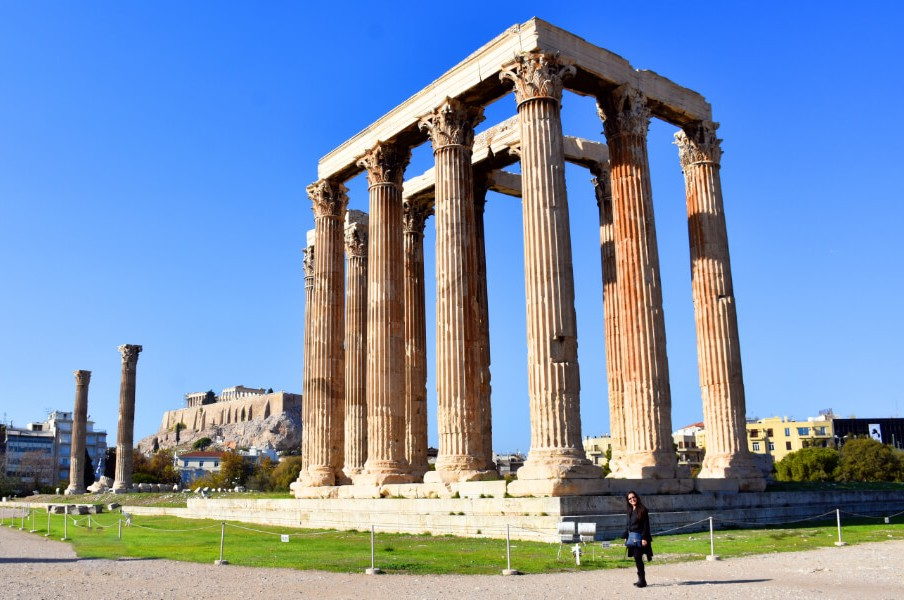

In [34]:
# See currently stored memory

thread_id = "travel_chat"

config = {
    "configurable": {
        "thread_id": thread_id
    }
}

state = agent.get_state(config)

print("===== CURRENT MEMORY =====")

if not state.values.get("messages"):
    print("No memory stored yet.")
else:
    for i, message in enumerate(state.values["messages"], 1):
        print(f"\n--- Message {i} ---")
        print("Type:", type(message).__name__)
        print("Content:", message.content)

In [31]:
# 🧹 Clear current TravelMate memory

memory.storage.clear()

print("Current memory cleared! 🧹")

Current memory cleared! 🧹
